In [1]:
%load_ext autoreload
%autoreload 2

# Define autroreload so that it doesn't cause pain in the ass when we change the functions and run this notebook

In [2]:
import sys
from pathlib import Path
project_root = Path.cwd().resolve().parents[2]
sys.path.append(str(project_root))

print(project_root)

from defs.diffusion.diffusion import *
from defs.diffusion.epsilon import *
from defs.diffusion.training_defs import *
from defs.diffusion.loss import *
from defs.diffusion.noise_scheduling import *
from defs.diffusion.noise_sampling import *

import torch.optim as optim

C:\SenkDosya\Projects\FINCH-Science_SyntheticData


In [ ]:
# Predefine all the necessary inputs of the training function

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# Loss:
loss = loss_mse_sam(1)

# Epsilon:
cfg_model = {
    'time_embed': {
        'hidden_dim': 48,
        'hidden_n': 2
    },
    'ab_embed': {
        'hidden_dim': 64,
        'hidden_n': 2,
        'ab_dim': 3
    },
    'denoiser': {
        'hidden_dim': 256,
        'hidden_n': 4,
        'spec_dim': 81
    }
}
epsilon= Epsilon_MLP(cfg_model= cfg_model)
epsilon = epsilon.to(device)

print('N of params in epsillon: ', get_n_params(epsilon))

# Scheduler:
scheduler = CosSchedule(2000)

# T sampler:
t_sampler = NormalSampling(scheduler=scheduler, t_min=0, containment_percentage=0.995)

# DDPM:
cfg_diffusion = {
    't_sampler': t_sampler
}
ddpm = cond_diffusion(epsilon=epsilon, scheduler=scheduler, ddpm_dict=cfg_diffusion)

# Optimizer:
optimizer = optim.Adam(epsilon.parameters(), lr=1e-4)




<>:47: SyntaxWarning: invalid escape sequence '\d'
<>:47: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Ege Artan\AppData\Local\Temp\ipykernel_20488\3560854392.py:47: SyntaxWarning: invalid escape sequence '\d'
  data_handle = str(project_root)+'\data\simpler_data_rwc.csv'


cuda
N of params in epsillon:  353537


In [ ]:

# Data handle:
data_handle = str(project_root)+'\data\simpler_data_rwc.csv'

# cfg_train:
cfg_train = {
    'cfg_loader': {
        'test': 23, 't_batch': 1, 'validate': 4, 'epoch': 50
    },
    'range': [900, 1700],
    'device': device,
    'tot_samples': 1723
}

# Figure out the data

# First, we will pre-process and parse all the data
# Get the spectral range that we want to use
spec_range = cfg_train.get('range', [400, 2490])

# Parse the csv into sub-parts we want to use
spectra, abundances, names, indices = get_vals(data_handle=data_handle, spec_range=spec_range, normalize=True)

# Generate the hyperspectral dataset
ds = HyperSpectralDataset(spectra=spectra, abundances=abundances, names=names, indices=indices)

# Dataload the giant dataset into train, test, validation datasets
cfg_loader = cfg_train.get(
    'cfg_loader', {'test': 23, 't_batch': 1, 'validate': 4, 'epoch': 50}
) # Get the configs for the loader first

# Get the dataloaded datasets
dataloaders= get_dataloaders(ds, cfg_loader=cfg_loader)

In [5]:
collector_dict, ddpm = train_diffusion(
    cfg_train= cfg_train, cond_diffusion= ddpm, loss= loss, optimizer= optimizer, dataloaders= dataloaders 
)

Epoch 1 | Batch 1 | Total loss: 1.8882 | Epsilon loss: 0.9467 | Recons loss: 0.9416
Epoch 1 | Batch 2 | Total loss: 1.0810 | Epsilon loss: 1.0810 | Recons loss: 0.0000
Epoch 1 | Batch 3 | Total loss: 2.2498 | Epsilon loss: 0.9453 | Recons loss: 1.3045
Epoch 1 | Batch 4 | Total loss: 1.9314 | Epsilon loss: 1.0897 | Recons loss: 0.8416
Epoch 1 | Batch 5 | Total loss: 2.1375 | Epsilon loss: 1.3534 | Recons loss: 0.7841
Epoch 1 | Batch 6 | Total loss: 1.9773 | Epsilon loss: 0.9520 | Recons loss: 1.0252
Epoch 1 | Batch 7 | Total loss: 1.8655 | Epsilon loss: 0.7874 | Recons loss: 1.0781
Epoch 1 | Batch 8 | Total loss: 1.8263 | Epsilon loss: 1.2439 | Recons loss: 0.5824
Epoch 1 | Batch 9 | Total loss: 1.6279 | Epsilon loss: 0.9633 | Recons loss: 0.6646
Epoch 1 | Batch 10 | Total loss: 1.3948 | Epsilon loss: 0.6458 | Recons loss: 0.7490
Epoch 1 | Batch 11 | Total loss: 1.5077 | Epsilon loss: 0.9575 | Recons loss: 0.5502
Epoch 1 | Batch 12 | Total loss: 2.0636 | Epsilon loss: 0.8875 | Recons lo

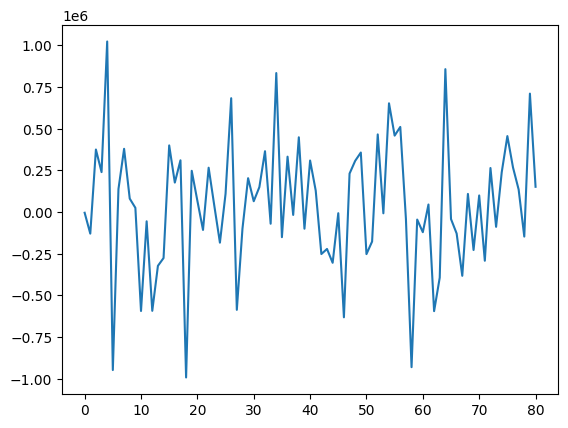

In [6]:
import matplotlib.pyplot as plt

spectrum = collector_dict['gen_spec']['validate'][50]['generated'][3]

wavelengths = np.arange(spectrum.shape[0])

plt.plot(wavelengths, spectrum)
plt.show()


In [6]:
print(spectra[300])

tensor([ 2.4170e-01,  2.4238e-01,  2.3984e-01,  2.2939e-01,  2.2008e-01,
         1.9156e-01,  1.5881e-01,  1.4316e-01,  1.4069e-01,  1.4586e-01,
         1.4644e-01,  1.4976e-01,  1.6557e-01,  1.8157e-01,  1.9589e-01,
         2.0709e-01,  2.1535e-01,  2.2021e-01,  2.2099e-01,  2.1834e-01,
         2.1305e-01,  2.0910e-01,  2.0357e-01,  1.6585e-01,  1.0642e-01,
         3.9066e-02, -2.5392e-05, -1.1665e-02, -1.6143e-02, -2.0066e-02,
        -1.8673e-02, -1.3450e-02, -5.2521e-03,  3.3221e-03,  1.2164e-02,
         2.0842e-02,  2.6669e-02,  2.6901e-02,  2.2478e-02,  1.1954e-02,
        -6.5995e-03, -3.4654e-02, -7.2991e-02, -1.1698e-01, -1.5754e-01,
        -1.6902e-01, -1.6290e-01, -1.3162e-01, -1.8767e-01, -1.9344e-01,
        -3.0574e-01, -4.9354e-01, -6.8026e-01, -7.4847e-01, -7.7010e-01,
        -7.9137e-01, -7.9559e-01, -7.8418e-01, -7.6872e-01, -7.5245e-01,
        -7.3265e-01, -7.0811e-01, -6.8175e-01, -6.5473e-01, -6.2738e-01,
        -6.0070e-01, -5.7568e-01, -5.5169e-01, -5.2